In [1]:
import sys
# Change to repository root, so it can find the config folder with the paths inside it
GITHUB_REPO_PATH = '/Users/maxwellrosen/Storage/Salk_Plant_Imaging/eckerlabproj'
# Add config folder with paths to Python's import search path
if GITHUB_REPO_PATH not in sys.path:
    sys.path.insert(0, GITHUB_REPO_PATH)

import config.paths as paths

In [2]:
# only needed in Jupyter Lab to see the images inline
%matplotlib widget

from plantcv import plantcv as pcv
from plantcv.parallel import WorkflowInputs
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import json
import shutil

In [63]:
image_path = '/Users/maxwellrosen/Library/CloudStorage/GoogleDrive-salkimager@gmail.com/My Drive/Chamber/CLeft_Holder/Tray2_Holder/ChamberLeft_image_2025-12-18--16-55.jpg'
# Change to Chamber folder: this is where the temporary data on pixel number in plants is saved
t1_temp_chamber_image_results = paths.t1_temp_pixel_results
# Change to location where data from this run is saved
analysis_results_csv_path = paths.t1_analysis_results
# Change to location where plant_names.csv is saved
plant_names_path = paths.t1_plant_names

In [64]:
# Input/output options for PlantCV
args = WorkflowInputs(
    images=[image_path],
    names="image",
    result=t1_temp_chamber_image_results, 
    outdir=".",
    writeimg=False,
    debug="plot"
    )

# Set debug to the global parameter 
pcv.params.debug = args.debug
# Change display settings
pcv.params.dpi = 100
# Increase text size and thickness to make labels clearer
# (size may need to be altered based on original image size)
pcv.params.text_size = 10
pcv.params.text_thickness = 20

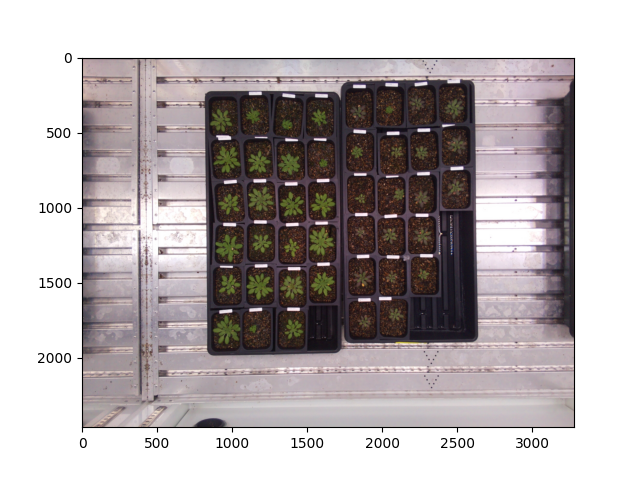

In [65]:
# Shows your image, defines it as "img"
img, path, filename = pcv.readimage(filename=args.image)

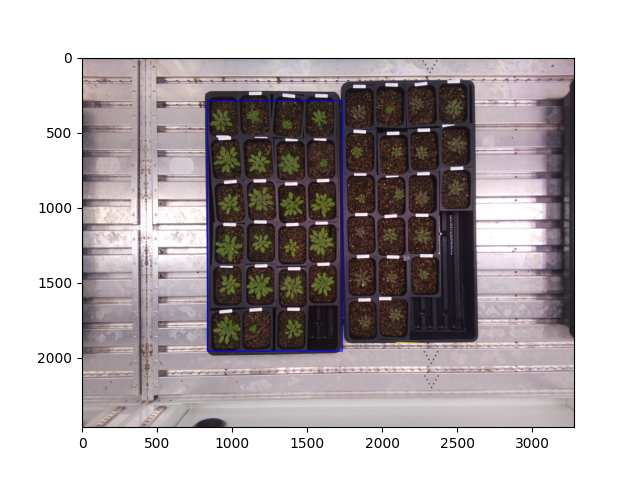

In [66]:
# Crops your image
crop_img = pcv.crop(img=img, x=835, y=290, w=900, h=1669)

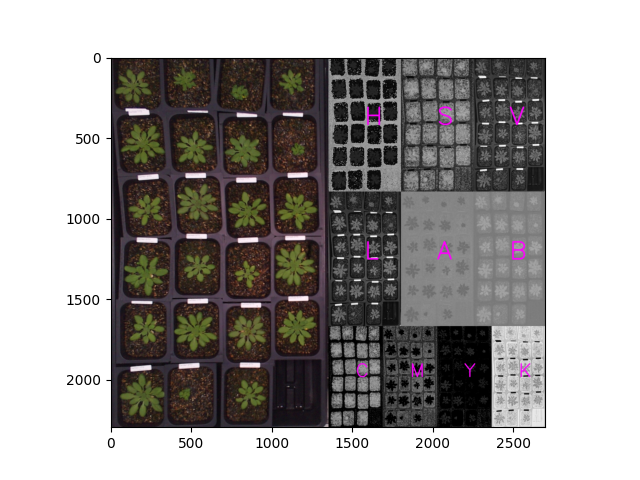

In [67]:
# Shows options for which channel to view the image through (ideally want the most contrast)
colorspace_img = pcv.visualize.colorspaces(rgb_img=crop_img)

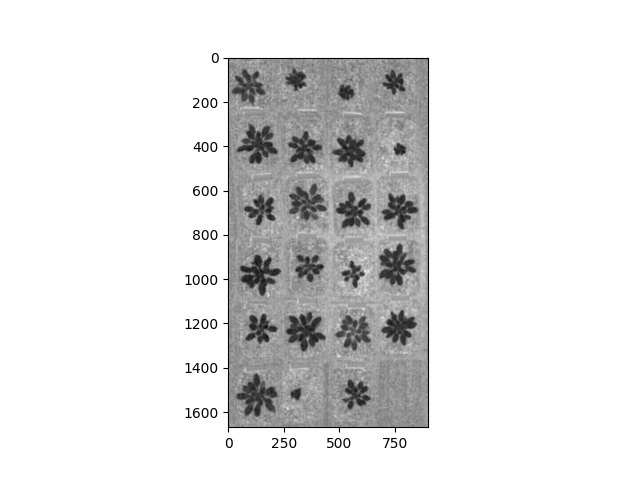

In [68]:
# Actually picks a channel with rgb2gray_"lab" and then the channel is the letter from "lab" that you look through
channeled_img = pcv.rgb2gray_lab(rgb_img=crop_img, channel='a')

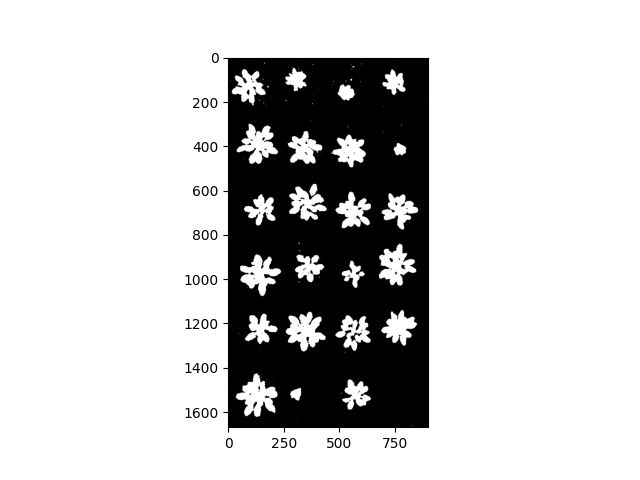

In [69]:
# Masks the image
thresh_mask = pcv.threshold.binary(gray_img=channeled_img, threshold=125, object_type='dark')

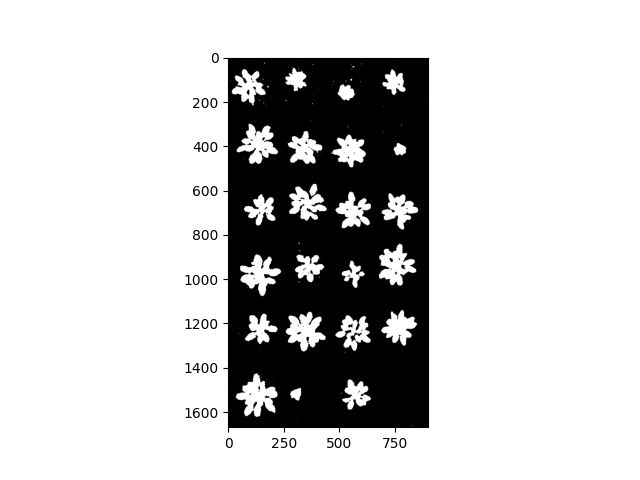

In [78]:
# Deletes groups of pixels less than the pixel size (weird dots around edges not plant is unmasked)
cleaned_mask = pcv.fill(bin_img=thresh_mask, size=0)

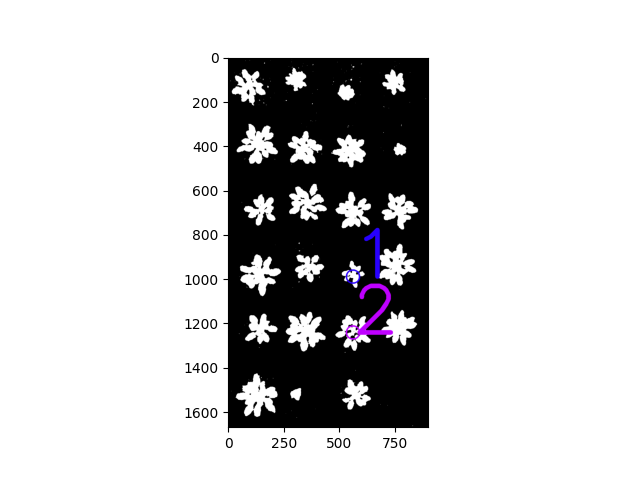

In [80]:
# Defines many Region of Interests (ROI) which selects white pixels and deselects black pixels from a masked image, based from little circles around each plant with coordinates we define
rois = pcv.roi.multi(img=cleaned_mask, 
                    coord=[(562,990), (562, 1242)],
                    radius=30)

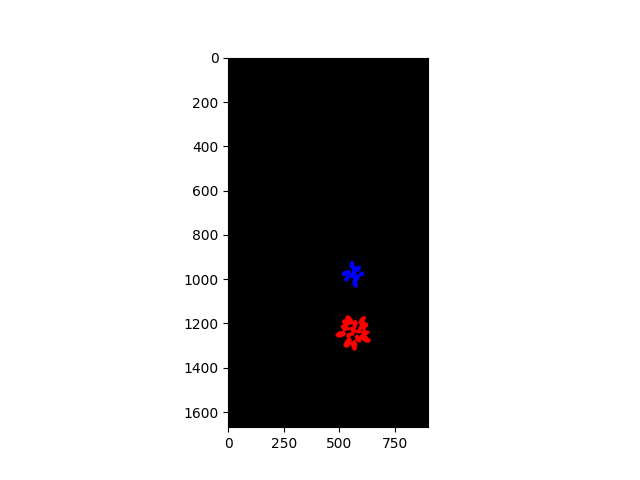

In [81]:
# Label and number objects in ROI; A good check to ensure different plants are different objects from being different colors
labeled_mask, num_plants = pcv.create_labels(mask=cleaned_mask, rois=rois, roi_type='partial')

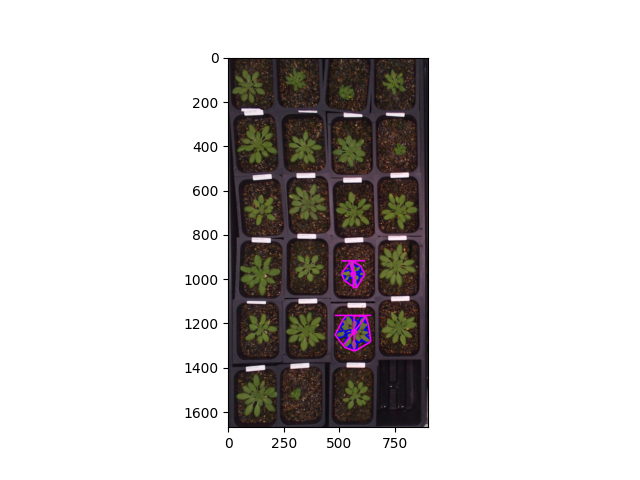

In [82]:
# Outputs analyzed image
shape_image = pcv.analyze.size(img=crop_img, labeled_mask=labeled_mask, n_labels=num_plants)

In [83]:
# Saves results for the 1 image (running again overwites past results)
pcv.outputs.save_results(filename= args.result, outformat="json")

In [84]:
scale_values_path = paths.t1_scale_values_path
# Gets pixels to mm scalar s (mm per pixel, so: pixels * s^2 = mm^2)
with open(scale_values_path, "r") as f:
    scale_data = json.load(f)

mean_s = scale_data["mean_scale_mm_per_pixel"]
std_s = scale_data["std_scale_mm_per_pixel"]

In [85]:
pixels_value = pcv.outputs.observations[f"default_{1}"]["area"]["value"]
print(pixels_value * (mean_s ** 2))

pixels_value = pcv.outputs.observations[f"default_{2}"]["area"]["value"]
print(pixels_value * (mean_s ** 2))

551.751427696665
1346.667746476764


In [77]:
plt.close('all')